# Building the Linear Regression Model — Lena Sophie

> ### Read this first — the data underneath this notebook has changed
>
> **The fit below is stale.** Nothing in it has been altered except the file
> paths in the loading cell, so every number, plot and conclusion still comes
> from the old 448-row dataset. Re-run it against the new data before trusting
> anything, and expect some of it to move.
>
> #### What happened
>
> The collector was sending an invalid `mutter` flag on every request, and
> Trassenfinder rejected 40 of the 96 German ONTD segments outright. The loss
> was not random: the rejected segments averaged 76 km against 136 km for the
> ones that survived, so **the short-distance end of the curve was missing
> entirely** when this model was fitted. That has been fixed, along with a bad
> DS100 code for Köln Süd and a segment with no station code at all.
>
> A second route sample was also collected — 100 generated station pairs, of
> which 53 returned results — to extend the range past where real night-train
> segments reach.
>
> #### What you have now
>
> | file | rows | routes | distance range |
> |---|---|---|---|
> | `data/samples_ontd.csv` | 760 | 95 | 3.8 – 817 km |
> | `data/samples_synthetic.csv` | 424 | 53 | 87 – 941 km |
> | `data/samples_all.csv` | 1,184 | 148 | 3.8 – 941 km |
>
> Same columns as before, plus a `source` column marking which sample a row came
> from. The loading cell below reads `samples_ontd.csv` — the direct successor of
> the file this notebook used — and the other two are one line away.
>
> #### Things worth looking at again
>
> These are questions, not corrections. Some may turn out fine.
>
> 1. **The quadratic distance term.** It came out negative, which means total
>    energy eventually falls as a route gets longer. That was fitted with the
>    short segments missing. Look at energy per km against distance now that
>    they are back, and see whether the shape you assumed still fits — and what
>    the term implies for a 1,500 km route, well past anything in the data.
> 2. **The average-speed coefficient.** Also negative: faster is cheaper,
>    holding distance and weight fixed. Your own note called this an operational
>    effect rather than a causal one. Worth asking what happens in the backend
>    if someone raises a train's `v_max` and the model responds by predicting
>    less energy — and whether `avg_speed_kmh`, which is computed from the same
>    distance that is already a predictor, can be separated from it at all.
> 3. **The centering constants.** The last cell raises `NameError` before
>    printing them, and nothing else records them. The exported coefficients are
>    for centered variables, so without those three means they cannot be used.
>    Either persist them alongside the coefficients, or fit uncentered — the
>    centering was only ever a diagnostic for the VIF check, and it changes
>    neither the fit nor the predictions.
> 4. **Where the model gets applied.** `calc_energy_consumption.py` predicts per
>    *country leg* — a stretch of route inside one country — not per station-to-
>    station segment. A 1,200 km leg may be split at two borders. Try predicting
>    a route whole, then as several pieces, and check the totals agree. If they
>    do not, the functional form is the reason.
> 5. **Whether the two samples can be pooled.** Fit each separately and compare
>    the coefficients. If they agree, use `samples_all.csv` and gain the 400 –
>    941 km range where the ONTD sample is thin. If they disagree, that is worth
>    understanding before pooling.
>
> #### One gotcha in the merge
>
> Köln Süd was corrected from `KKSU` to `KKS` during collection, but
> `sources/routes_ontd.csv` still carries the original code. Two segments,
> 16 rows, will not match on the DS100 join key — your `isna()` check in the
> verification cell will show them. Decide deliberately whether to fix the route
> list or the join.
>
> #### Running it
>
> Launch Jupyter from `backend/` and open this folder:
>
> ```
> uv run --extra dev jupyter lab --notebook-dir models/energy/calib
> ```
>
> #### Where the sample files come from
>
> They are not in git — they are ~1,500 Trassenfinder calls, too slow to rebuild
> on demand — so they travel through a shared Drive folder instead. You do not
> have to fetch anything by hand: the loading cell calls `ensure_local()`, which
>
> - uses `data/<name>.csv` if it is already there, and downloads nothing;
> - otherwise pulls the folder from Drive, saves the file into `data/`, and
>   returns it.
>
> So the first run downloads and every run after that is local. A file already
> on disk is never overwritten, so a sample you collected yourself with
> `01_source_extraction.ipynb` always wins over the Drive copy. The cell prints
> which of the two happened.
>
> This needs `ENERGY_DRIVE_FOLDER_ID` in `backend/docker/.env` — ask David if
> you do not have it. Without it you get a clear error rather than a silent
> partial load. To collect the samples fresh instead, run
> `01_source_extraction.ipynb`; it takes 30–50 minutes.
>
> Background on the collection, the two route sources and why 47 generated
> routes failed is in [`README.md`](README.md).

Importing the data

In [1]:
# import the libraries
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Statistical modelling
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Train/test splitting and validation
from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    GroupKFold,
    cross_validate
)

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# import the datasets
#
# Route lists and compositions are committed under sources/. The samples are
# not in git — they are ~1,500 Trassenfinder calls — so they live in data/ and
# ensure_local() fetches them from Drive the first time this machine needs
# them. After that the local copy is used and nothing is downloaded again.
from data_sources import DATA_DIR, SEED_DIR, ensure_local, source_input

# Which sample to fit on. "samples_ontd" is the real night-train segments and
# the direct successor of the file this notebook used to read; "samples_all"
# adds the generated station pairs and the 400-941 km range with them.
SAMPLE = "samples_all"  # or "samples_synthetic", or "samples_all"


def load_sample(name):
    """Read one sample file, downloading it from Drive if it isn't here yet."""
    path = DATA_DIR / f"{name}.csv"

    if path.is_file():
        print(f"{name}.csv — using the local copy in {DATA_DIR.name}/")
    else:
        print(f"{name}.csv — not here yet, fetching from Drive...")

    # Downloads and saves into data/ when missing; returns the local path
    # either way. A file already on disk is never overwritten.
    return pd.read_csv(ensure_local(f"{name}.csv"))


ontd_segments = pd.read_csv(source_input("routes_ontd.csv"))
compositions = pd.read_csv(source_input("compositions.csv"))
energy = load_sample(SAMPLE)

print(
    f"  {len(energy)} rows, {energy['composition_id'].nunique()} compositions, "
    f"distance {energy['distance_km'].min():.1f} - {energy['distance_km'].max():.1f} km"
)

samples_all.csv — using the local copy in data/
  1184 rows, 8 compositions, distance 3.8 - 941.1 km


In [3]:
# inspection

print(energy.shape)
print(energy.columns)

print(ontd_segments.shape)
print(ontd_segments.columns)

print(compositions.shape)
print(compositions.columns)

(1184, 14)
Index(['source', 'route_name', 'start_stop_name', 'start_ds100',
       'end_stop_name', 'end_ds100', 'composition_id', 'n_coaches', 'weight_t',
       'length_m', 'v_max_kmh', 'energy_kwh', 'distance_km',
       'travel_time_min'],
      dtype='str')
(96, 11)
Index(['route_name', 'all_routes_serving_segment', 'start_stop_id',
       'start_stop_name', 'start_ds100', 'end_stop_id', 'end_stop_name',
       'end_ds100', 'travel_duration_min', 'air_distance_km',
       'n_trip_occurrences'],
      dtype='str')
(8, 18)
Index(['composition_id', 'description', 'material_strategy', 'n_coaches',
       'total_places', 'places_by_class', 'loco_name', 'loco_baureihe',
       'trassenfinder_triebfahrzeug_hauptnummer', 'loco_weight_t',
       'loco_length_m', 'v_max_kmh', 'coaches_length_m_wagenzuglaenge',
       'coaches_net_weight_t', 'pax_load_80pct_t',
       'coaches_gross_weight_80pct_t_wagenzugmasse',
       'coaches_gross_weight_100pct_t', 'total_weight_incl_loco_80pct_t'],
    

Building the dataset

In [4]:
# merge the dataframes

data = (
    energy
    .merge(
        ontd_segments,
        on=[
            "route_name",
            "start_ds100",
            "end_ds100"
        ],
        how="left",
        suffixes=("", "_segment")
    )
    .merge(
        compositions,
        on="composition_id",
        how="left",
        suffixes=("", "_composition")
    )
)

data["avg_speed_kmh"] = (
    data["distance_km"]
    / (data["travel_time_min"] / 60)
)

In [5]:
# verify the merged df

print(data.shape)

print(data.isna().sum().sort_values(ascending=False).head(20))

data["segment_id"] = (
    data["route_name"].astype(str)
    + "__"
    + data["start_ds100"].astype(str)
    + "__"
    + data["end_ds100"].astype(str)
)

print(data["segment_id"].nunique())
print(data["composition_id"].nunique())

print(
    data.groupby("segment_id")
    ["composition_id"]
    .nunique()
    .value_counts()
)

(1184, 40)
travel_duration_min           448
air_distance_km               440
end_stop_id                   440
start_stop_name_segment       440
start_stop_id                 440
n_trip_occurrences            440
all_routes_serving_segment    440
end_stop_name_segment         440
n_coaches                       0
composition_id                  0
end_ds100                       0
end_stop_name                   0
start_ds100                     0
start_stop_name                 0
route_name                      0
source                          0
distance_km                     0
travel_time_min                 0
v_max_kmh                       0
energy_kwh                      0
dtype: int64
148
8
composition_id
8    148
Name: count, dtype: int64


In [6]:
# split into training and test datasets

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        data,
        groups=data["segment_id"]
    )
)

train = data.iloc[train_idx].copy()
test = data.iloc[test_idx].copy()

In [7]:
# leakage check

train_segments = set(train["segment_id"])
test_segments = set(test["segment_id"])

assert train_segments.isdisjoint(test_segments)

print("Training rows:", len(train))
print("Test rows:", len(test))

print("Training segments:", train["segment_id"].nunique())
print("Test segments:", test["segment_id"].nunique())

Training rows: 944
Test rows: 240
Training segments: 118
Test segments: 30


First regression model

In [8]:
# build an initial model

# centering the values
train["distance_c"] = (
    train["distance_km"]
    - train["distance_km"].mean()
)

train["weight_c"] = (
    train["weight_t"]
    - train["weight_t"].mean()
)

test["distance_c"] = (
    test["distance_km"]
    - train["distance_km"].mean()
)

test["weight_c"] = (
    test["weight_t"]
    - train["weight_t"].mean()
)

speed_mean = train["avg_speed_kmh"].mean()

train["speed_c"] = (
    train["avg_speed_kmh"] - speed_mean
)

test["speed_c"] = (
    test["avg_speed_kmh"] - speed_mean
)

model_initial = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + weight_t
    + v_max_kmh
    + avg_speed_kmh
    """,
    data=train
).fit()

print(model_initial.summary())

                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     4710.
Date:                Fri, 28 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:56:45   Log-Likelihood:                -6785.4
No. Observations:                 944   AIC:                         1.358e+04
Df Residuals:                     939   BIC:                         1.360e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -1107.9033    191.850     -5.775

As v_max_kmh and avg_speed_kmh could be strongly correlated, conduct a correlation check and VIF

In [9]:
cols = [
    "distance_km",
    "weight_t",
    "v_max_kmh",
    "avg_speed_kmh",
    "energy_kwh"
]

print(train[cols].corr())

               distance_km  weight_t  v_max_kmh  avg_speed_kmh  energy_kwh
distance_km       1.000000  0.001147  -0.000133       0.239497    0.957313
weight_t          0.001147  1.000000  -0.059288      -0.066088    0.188306
v_max_kmh        -0.000133 -0.059288   1.000000      -0.001062    0.008197
avg_speed_kmh     0.239497 -0.066088  -0.001062       1.000000    0.191983
energy_kwh        0.957313  0.188306   0.008197       0.191983    1.000000


In [10]:
X = train[
    [
        "distance_km",
        "weight_t",
        "v_max_kmh",
        "avg_speed_kmh"
    ]
].copy()

X = sm.add_constant(X)

vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

print(vif)

        variable         VIF
0          const  337.089480
1    distance_km    1.061176
2       weight_t    1.008265
3      v_max_kmh    1.003554
4  avg_speed_kmh    1.065857


No problematic multicollinearity observed. However, v_max_kmh is basically uncorrelated, so test a model without it

In [11]:
model_no_vmax = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + weight_t
    + avg_speed_kmh
    """,
    data=train
).fit()

model_with_vmax = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + weight_t
    + avg_speed_kmh
    + v_max_kmh
    """,
    data=train
).fit()

print(model_no_vmax.aic, model_with_vmax.aic)
print(model_no_vmax.bic, model_with_vmax.bic)
print(model_with_vmax.summary())

13586.125636518482 13580.727363870164
13605.526141183063 13604.977994700892
                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     4710.
Date:                Fri, 28 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:56:45   Log-Likelihood:                -6785.4
No. Observations:                 944   AIC:                         1.358e+04
Df Residuals:                     939   BIC:                         1.360e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

Now test the models on the test set

In [12]:
models = {
    "without_vmax": model_no_vmax,
    "with_vmax": model_with_vmax
}

results = []

for name, model in models.items():
    pred = model.predict(test)

    results.append({
        "model": name,
        "MAE": mean_absolute_error(
            test["energy_kwh"], pred
        ),
        "RMSE": mean_squared_error(
            test["energy_kwh"], pred
        ) ** 0.5,
        "R2": r2_score(
            test["energy_kwh"], pred
        )
    })

print(pd.DataFrame(results))

          model         MAE        RMSE        R2
0  without_vmax  283.504610  371.361349  0.948746
1     with_vmax  282.367072  370.026245  0.949114


The results show that it's a marginal case - for v_max_kmh, AIC prefers retention, BIC prefers dropping, test performance suggests marginal improvement. Therefore, it is plausible that this variable might be used as interaction

Hence, build some models with and without that variable and as independent and interaction terms

In [13]:
formula_base = """
energy_kwh
~ distance_km
+ weight_t
+ avg_speed_kmh
"""

formula_vmax = """
energy_kwh
~ distance_km
+ weight_t
+ avg_speed_kmh
+ v_max_kmh
"""

# distance-weight interaction
formula_weight_interaction = """
energy_kwh
~ distance_km
+ weight_t
+ avg_speed_kmh
+ v_max_kmh
+ distance_km:weight_t
"""

# distance-weight and distance-vmax interaction
formula_vmax_interaction = """
energy_kwh
~ distance_km
+ weight_t
+ avg_speed_kmh
+ v_max_kmh
+ distance_km:weight_t
+ distance_km:v_max_kmh
"""

In [14]:
# GroupKFold comparison

In [15]:
formulas = {
    "base": formula_base,
    "vmax": formula_vmax,
    "weight_interaction": formula_weight_interaction,
    "weight_and_vmax_interaction": formula_vmax_interaction
}

gkf = GroupKFold(n_splits=5)

results = []

for model_name, formula in formulas.items():

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(train, groups=train["segment_id"]),
        start=1
    ):

        cv_train = train.iloc[train_idx].copy()
        cv_val = train.iloc[val_idx].copy()

        model = smf.ols(
            formula,
            data=cv_train
        ).fit()

        pred = model.predict(cv_val)

        results.append({
            "model": model_name,
            "fold": fold,
            "MAE": mean_absolute_error(
                cv_val["energy_kwh"],
                pred
            ),
            "RMSE": mean_squared_error(
                cv_val["energy_kwh"],
                pred
            ) ** 0.5,
            "R2": r2_score(
                cv_val["energy_kwh"],
                pred
            )
        })

cv_results = pd.DataFrame(results)

summary = (
    cv_results
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_sd=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_sd=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_sd=("R2", "std")
    )
    .sort_values("RMSE_mean")
)

print(summary)

                               MAE_mean     MAE_sd   RMSE_mean    RMSE_sd  \
model                                                                       
weight_and_vmax_interaction  137.845532  33.477989  198.088998  33.856755   
weight_interaction           139.742579  33.353890  200.034197  34.089466   
vmax                         248.349779  34.059831  324.927216  42.237770   
base                         249.672125  34.276844  326.115240  42.475785   

                              R2_mean     R2_sd  
model                                            
weight_and_vmax_interaction  0.980683  0.004781  
weight_interaction           0.980308  0.004831  
vmax                         0.948434  0.006517  
base                         0.948068  0.006453  


RMSE is reduced by a third by adding the weight-distance interaction, but does not further decrease with the vmax interaction. Only small improvements are observed by adding this interaction. Therefore, test the two interaction models.

In [16]:
model_weight_interaction = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + weight_t
    + avg_speed_kmh
    + v_max_kmh
    + distance_km:weight_t
    """,
    data=train
).fit()

model_weight_vmax_interaction = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + weight_t
    + avg_speed_kmh
    + v_max_kmh
    + distance_km:weight_t
    + distance_km:v_max_kmh
    """,
    data=train
).fit()

print(model_weight_interaction.aic)
print(model_weight_interaction.bic)

print(model_weight_vmax_interaction.aic)
print(model_weight_vmax_interaction.bic)

print(model_weight_vmax_interaction.summary())

12628.673346339538
12657.774103336411
12610.935327052966
12644.886210215986
                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     9073.
Date:                Fri, 28 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:56:46   Log-Likelihood:                -6298.5
No. Observations:                 944   AIC:                         1.261e+04
Df Residuals:                     937   BIC:                         1.264e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [17]:
distance_mean = train["distance_km"].mean()
weight_mean = train["weight_t"].mean()
vmax_mean = train["v_max_kmh"].mean()
speed_mean = train["avg_speed_kmh"].mean()

for df in [train, test]:
    df["distance_c"] = df["distance_km"] - distance_mean
    df["weight_c"] = df["weight_t"] - weight_mean
    df["vmax_c"] = df["v_max_kmh"] - vmax_mean
    df["speed_c"] = df["avg_speed_kmh"] - speed_mean


model_weight_vmax_centered = smf.ols(
    """
    energy_kwh
    ~ distance_c
    + weight_c
    + speed_c
    + vmax_c
    + distance_c:weight_c
    + distance_c:vmax_c
    """,
    data=train
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": train["segment_id"]
    }
)

print(model_weight_vmax_centered.summary())

                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     2181.
Date:                Fri, 28 Aug 2026   Prob (F-statistic):          1.50e-117
Time:                        12:56:46   Log-Likelihood:                -6298.5
No. Observations:                 944   AIC:                         1.261e+04
Df Residuals:                     937   BIC:                         1.264e+04
Df Model:                           6                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1494.3434    

In [18]:
# run the vif again

X = train[
    [
        "distance_c",
        "weight_c",
        "speed_c",
        "vmax_c"
    ]
].copy()

X["distance_weight"] = (
    train["distance_c"] * train["weight_c"]
)

X["distance_vmax"] = (
    train["distance_c"] * train["vmax_c"]
)

X = sm.add_constant(X)

vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

print(vif)

          variable       VIF
0            const  1.000001
1       distance_c  1.061178
2         weight_c  1.008265
3          speed_c  1.066128
4           vmax_c  1.003554
5  distance_weight  1.003752
6    distance_vmax  1.003492


Now test whether we need a quadratic distance term

In [19]:
formula_interaction = """
energy_kwh
~ distance_c
+ weight_c
+ speed_c
+ vmax_c
+ distance_c:weight_c
+ distance_c:vmax_c
"""

formula_quadratic = """
energy_kwh
~ distance_c
+ I(distance_c ** 2)
+ weight_c
+ speed_c
+ vmax_c
+ distance_c:weight_c
+ distance_c:vmax_c
"""

In [20]:
formulas = {
    "interaction": formula_interaction,
    "quadratic": formula_quadratic
}

gkf = GroupKFold(n_splits=5)

results = []

for model_name, formula in formulas.items():

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(train, groups=train["segment_id"]),
        start=1
    ):

        cv_train = train.iloc[train_idx].copy()
        cv_val = train.iloc[val_idx].copy()

        model = smf.ols(
            formula,
            data=cv_train
        ).fit()

        pred = model.predict(cv_val)

        results.append({
            "model": model_name,
            "fold": fold,
            "MAE": mean_absolute_error(
                cv_val["energy_kwh"],
                pred
            ),
            "RMSE": mean_squared_error(
                cv_val["energy_kwh"],
                pred
            ) ** 0.5,
            "R2": r2_score(
                cv_val["energy_kwh"],
                pred
            )
        })

cv_results = pd.DataFrame(results)

summary = (
    cv_results
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_sd=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_sd=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_sd=("R2", "std")
    )
    .sort_values("RMSE_mean")
)

print(summary)

               MAE_mean     MAE_sd   RMSE_mean    RMSE_sd   R2_mean     R2_sd
model                                                                        
quadratic    137.483383  34.150028  196.821412  33.800045  0.980994  0.004342
interaction  137.845532  33.477989  198.088998  33.856755  0.980683  0.004781


The quadratic term actually worsens the model with higher mean RMSE and MAE values, thus it should not be in the model

Now run the candidate model and test it

In [21]:
model_candidate = smf.ols(
    """
    energy_kwh
    ~ distance_c
    + weight_c
    + speed_c
    + vmax_c
    + distance_c:weight_c
    + distance_c:vmax_c
    """,
    data=train
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": train["segment_id"]
    }
)

In [22]:
pred = model_candidate.predict(test)

mae = mean_absolute_error(
    test["energy_kwh"],
    pred
)

rmse = mean_squared_error(
    test["energy_kwh"],
    pred
) ** 0.5

r2 = r2_score(
    test["energy_kwh"],
    pred
)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R²:", r2)

Test MAE: 145.95095979011654
Test RMSE: 221.4980643418958
Test R²: 0.9817664585680784


In [23]:
test["predicted_energy_kwh"] = pred

test["absolute_error"] = (
    test["energy_kwh"]
    - test["predicted_energy_kwh"]
).abs()

test["relative_error_pct"] = (
    test["absolute_error"]
    / test["energy_kwh"]
    * 100
)

print(
    "Median relative error:",
    test["relative_error_pct"].median()
)

print(
    "Mean relative error:",
    test["relative_error_pct"].mean()
)

Median relative error: 8.943391110120734
Mean relative error: 23.9986493018038


At 23.08%, the mean relative error should be investigated. 

In [24]:
worst_relative = (
    test[
        [
            "segment_id",
            "composition_id",
            "energy_kwh",
            "predicted_energy_kwh",
            "absolute_error",
            "relative_error_pct",
            "distance_km",
            "weight_t",
            "avg_speed_kmh",
            "v_max_kmh"
        ]
    ]
    .sort_values(
        "relative_error_pct",
        ascending=False
    )
    .head(15)
)

print(worst_relative)

print(
    test["relative_error_pct"].describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

wape = (
    test["absolute_error"].sum()
    / test["energy_kwh"].sum()
    * 100
)

print("WAPE:", wape)

               segment_id composition_id  energy_kwh  predicted_energy_kwh  \
216     452 = 453__DH__DN      REF-BUD-6          30            154.974284   
217     452 = 453__DH__DN    REF-COUCH-6          30            154.181595   
222     452 = 453__DH__DN      NEW-BAL-7          31            149.273487   
219     452 = 453__DH__DN   REF-COUCH-10          46            206.689097   
220     452 = 453__DH__DN     REF-BUD-12          54            214.756145   
221     452 = 453__DH__DN    REF-PREM-12          54            214.414189   
223     452 = 453__DH__DN     NEW-BAL-14          54            213.846651   
218     452 = 453__DH__DN      REF-BAL-9          44            164.109908   
1084  SYN-075__RSGO__FBGK     REF-BUD-12        1303           2099.663348   
1085  SYN-075__RSGO__FBGK    REF-PREM-12        1299           2089.384676   
1082  SYN-075__RSGO__FBGK      REF-BAL-9        1121           1780.915211   
1083  SYN-075__RSGO__FBGK   REF-COUCH-10        1173           1

### However!
A better approach is, because of the kWh/km output requirement, to first calculate kWh/km and then multiply the distance

In [25]:
data["energy_kwh_per_km"] = (
    data["energy_kwh"] / data["distance_km"]
)

train["energy_kwh_per_km"] = (
    train["energy_kwh"] / train["distance_km"]
)

test["energy_kwh_per_km"] = (
    test["energy_kwh"] / test["distance_km"]
)

In [26]:
model_intensity_base = smf.ols(
    """
    energy_kwh_per_km
    ~ weight_t
    + avg_speed_kmh
    + v_max_kmh
    """,
    data=train
).fit()

In [27]:
model_intensity_nonlinear = smf.ols(
    """
    energy_kwh_per_km
    ~ weight_t
    + avg_speed_kmh
    + I(avg_speed_kmh ** 2)
    + v_max_kmh
    + I(v_max_kmh ** 2)
    """,
    data=train
).fit()

Compare the two models

In [28]:
models = {
    "base": model_intensity_base,
    "nonlinear": model_intensity_nonlinear
}

results = []

for name, model in models.items():
    pred_intensity = model.predict(test)

    pred_energy = (
        pred_intensity
        * test["distance_km"]
    )

    mae = mean_absolute_error(
        test["energy_kwh"],
        pred_energy
    )

    rmse = mean_squared_error(
        test["energy_kwh"],
        pred_energy
    ) ** 0.5

    r2 = r2_score(
        test["energy_kwh"],
        pred_energy
    )

    wape = (
        (test["energy_kwh"] - pred_energy)
        .abs()
        .sum()
        / test["energy_kwh"].sum()
        * 100
    )

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "WAPE_pct": wape
    })

comparison = pd.DataFrame(results)

print(comparison)

       model         MAE        RMSE        R2   WAPE_pct
0       base  194.332067  300.785230  0.966376  11.497351
1  nonlinear  190.460857  294.761899  0.967710  11.268317


Compare the predicted kWh/km

In [29]:
test["pred_kwh_per_km_base"] = (
    model_intensity_base.predict(test)
)

test["pred_kwh_per_km_nonlinear"] = (
    model_intensity_nonlinear.predict(test)
)

In [30]:
scenario = pd.DataFrame({
    "weight_t": [600] * 8,
    "avg_speed_kmh": [60, 70, 80, 90, 100, 110, 120, 130],
    "v_max_kmh": [200] * 8
})

scenario["base"] = model_intensity_base.predict(scenario)
scenario["nonlinear"] = model_intensity_nonlinear.predict(scenario)

print(scenario)

   weight_t  avg_speed_kmh  v_max_kmh       base  nonlinear
0       600             60        200  10.053267  10.063508
1       600             70        200   9.196152   9.159024
2       600             80        200   8.339038   8.286979
3       600             90        200   7.481924   7.447373
4       600            100        200   6.624810   6.640206
5       600            110        200   5.767695   5.865478
6       600            120        200   4.910581   5.123189
7       600            130        200   4.053467   4.413339


The nonlinear model only marginally improves in performance. Run a grouped CV

In [31]:
formulas = {
    "base": """
        energy_kwh_per_km
        ~ weight_t
        + avg_speed_kmh
        + v_max_kmh
    """,

    "nonlinear": """
        energy_kwh_per_km
        ~ weight_t
        + avg_speed_kmh
        + I(avg_speed_kmh ** 2)
        + v_max_kmh
        + I(v_max_kmh ** 2)
    """
}

gkf = GroupKFold(n_splits=5)

results = []

for model_name, formula in formulas.items():

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(train, groups=train["segment_id"]),
        start=1
    ):

        cv_train = train.iloc[train_idx].copy()
        cv_val = train.iloc[val_idx].copy()

        model = smf.ols(
            formula,
            data=cv_train
        ).fit()

        pred_kwh_per_km = model.predict(cv_val)

        pred_energy = (
            pred_kwh_per_km
            * cv_val["distance_km"]
        )

        actual_energy = cv_val["energy_kwh"]

        mae = mean_absolute_error(
            actual_energy,
            pred_energy
        )

        rmse = mean_squared_error(
            actual_energy,
            pred_energy
        ) ** 0.5

        r2 = r2_score(
            actual_energy,
            pred_energy
        )

        wape = (
            (actual_energy - pred_energy)
            .abs()
            .sum()
            / actual_energy.sum()
            * 100
        )

        results.append({
            "model": model_name,
            "fold": fold,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "WAPE_pct": wape
        })

cv_results = pd.DataFrame(results)

summary = (
    cv_results
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_sd=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_sd=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_sd=("R2", "std"),
        WAPE_mean=("WAPE_pct", "mean"),
        WAPE_sd=("WAPE_pct", "std")
    )
)

print(summary)

             MAE_mean     MAE_sd   RMSE_mean     RMSE_sd   R2_mean     R2_sd  \
model                                                                          
base       165.361708  68.564402  247.422380  109.996726  0.966764  0.027426   
nonlinear  163.895008  67.492586  245.581414  106.646446  0.967366  0.026253   

           WAPE_mean   WAPE_sd  
model                           
base       10.873630  3.089593  
nonlinear  10.777889  3.028758  


The base model is slightly better on MAE, RMSE, and WAPE. The nonlinear model only has a negligible R2 advantage. Therefore take the base model. Now grouped CV with these two models, weil the avg_speed_kmh has a negative coefficient:

In [32]:
formulas = {
    "base": """
        energy_kwh_per_km
        ~ weight_t
        + avg_speed_kmh
        + v_max_kmh
    """,

    "without_avg_speed": """
        energy_kwh_per_km
        ~ weight_t
        + v_max_kmh
    """
}

gkf = GroupKFold(n_splits=5)

results = []

for model_name, formula in formulas.items():

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(train, groups=train["segment_id"]),
        start=1
    ):

        cv_train = train.iloc[train_idx].copy()
        cv_val = train.iloc[val_idx].copy()

        model = smf.ols(
            formula,
            data=cv_train
        ).fit()

        pred_kwh_per_km = model.predict(cv_val)

        pred_energy = (
            pred_kwh_per_km
            * cv_val["distance_km"]
        )

        actual_energy = cv_val["energy_kwh"]

        mae = mean_absolute_error(
            actual_energy,
            pred_energy
        )

        rmse = mean_squared_error(
            actual_energy,
            pred_energy
        ) ** 0.5

        r2 = r2_score(
            actual_energy,
            pred_energy
        )

        wape = (
            (actual_energy - pred_energy)
            .abs()
            .sum()
            / actual_energy.sum()
            * 100
        )

        results.append({
            "model": model_name,
            "fold": fold,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "WAPE_pct": wape
        })

cv_results = pd.DataFrame(results)

summary = (
    cv_results
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_sd=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_sd=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_sd=("R2", "std"),
        WAPE_mean=("WAPE_pct", "mean"),
        WAPE_sd=("WAPE_pct", "std")
    )
)

print(summary)

                     MAE_mean     MAE_sd  RMSE_mean     RMSE_sd   R2_mean  \
model                                                                       
base               165.361708  68.564402  247.42238  109.996726  0.966764   
without_avg_speed  186.269759  77.456350  277.10293   94.539487  0.961000   

                      R2_sd  WAPE_mean   WAPE_sd  
model                                             
base               0.027426  10.873630  3.089593  
without_avg_speed  0.023324  12.327448  3.745432  


avg_speed_kmh should be retained because removing it substantially degrades out-of-sample performance. Its negative coefficient is best interpreted as an operational association: at fixed train weight and maximum speed, higher average speed likely proxies for smoother operation, fewer restrictions/stops, or more efficient running conditions. It should not be interpreted as evidence that increasing speed causally reduces energy consumption.

In [33]:
#Sensitivity test

# chosen model
model_base = smf.ols(
    """
    energy_kwh_per_km
    ~ weight_t
    + avg_speed_kmh
    + v_max_kmh
    """,
    data=train
).fit()



In [34]:
scenario_avg = pd.DataFrame({
    "weight_t": [600] * 8,
    "avg_speed_kmh": [60, 70, 80, 90, 100, 110, 120, 130],
    "v_max_kmh": [200] * 8
})

scenario_avg["pred_kwh_per_km"] = model_base.predict(scenario_avg)

print(scenario_avg)

   weight_t  avg_speed_kmh  v_max_kmh  pred_kwh_per_km
0       600             60        200        10.053267
1       600             70        200         9.196152
2       600             80        200         8.339038
3       600             90        200         7.481924
4       600            100        200         6.624810
5       600            110        200         5.767695
6       600            120        200         4.910581
7       600            130        200         4.053467


In [35]:
scenario_vmax = pd.DataFrame({
    "weight_t": [600] * 6,
    "avg_speed_kmh": [100] * 6,
    "v_max_kmh": [140, 160, 180, 200, 220, 230]
})

scenario_vmax["pred_kwh_per_km"] = model_base.predict(scenario_vmax)

print(scenario_vmax)

   weight_t  avg_speed_kmh  v_max_kmh  pred_kwh_per_km
0       600            100        140         6.144601
1       600            100        160         6.304671
2       600            100        180         6.464740
3       600            100        200         6.624810
4       600            100        220         6.784879
5       600            100        230         6.864914


In [36]:
row = pd.DataFrame({
    "weight_t": [600],
    "avg_speed_kmh": [100],
    "v_max_kmh": [200]
})

intensity = float(model_base.predict(row).iloc[0])

whole_distance = 1200
whole_energy = intensity * whole_distance

legs = [400, 350, 450]
split_energy = sum(intensity * d for d in legs)

print("Whole:", whole_energy)
print("Split:", split_energy)
print("Difference:", split_energy - whole_energy)

Whole: 7949.771458165783
Split: 7949.771458165784
Difference: 9.094947017729282e-13


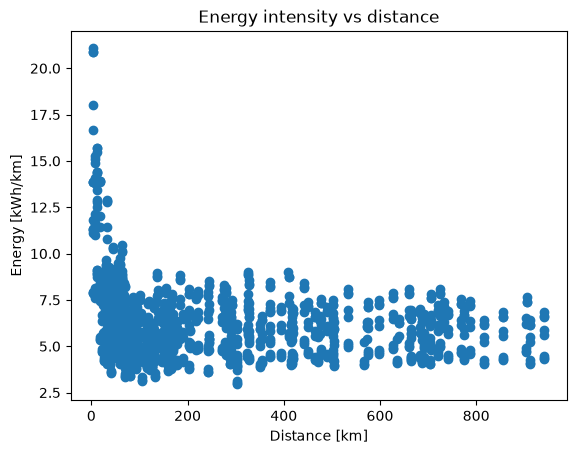

In [37]:
data["energy_kwh_per_km"] = (
    data["energy_kwh"] / data["distance_km"]
)

plt.figure()
plt.scatter(
    data["distance_km"],
    data["energy_kwh_per_km"]
)

plt.xlabel("Distance [km]")
plt.ylabel("Energy [kWh/km]")
plt.title("Energy intensity vs distance")
plt.show()

In [38]:
test["pred_kwh_per_km"] = model_base.predict(test)

test["actual_kwh_per_km"] = (
    test["energy_kwh"] / test["distance_km"]
)

test["intensity_residual"] = (
    test["actual_kwh_per_km"]
    - test["pred_kwh_per_km"]
)

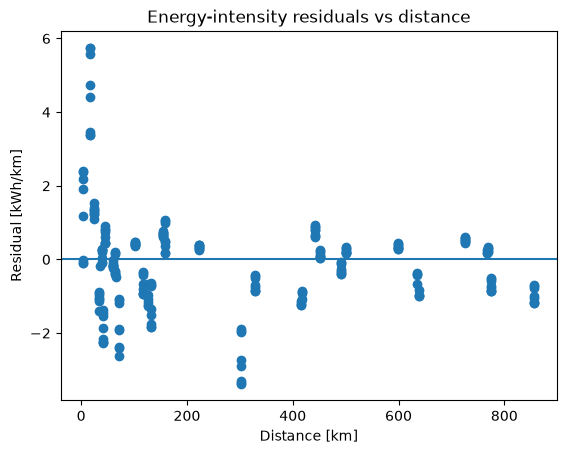

In [39]:
plt.figure()

plt.scatter(
    test["distance_km"],
    test["intensity_residual"]
)

plt.axhline(0)

plt.xlabel("Distance [km]")
plt.ylabel("Residual [kWh/km]")
plt.title("Energy-intensity residuals vs distance")

plt.show()

In [40]:
test["distance_band"] = pd.cut(
    test["distance_km"],
    bins=[0, 25, 50, 100, 200, 400, float("inf")],
    labels=[
        "0–25",
        "25–50",
        "50–100",
        "100–200",
        "200–400",
        "400+"
    ]
)

distance_performance = (
    test
    .groupby(
        "distance_band",
        observed=True
    )
    .agg(
        n=("energy_kwh", "size"),
        mean_actual_intensity=("actual_kwh_per_km", "mean"),
        mean_pred_intensity=("pred_kwh_per_km", "mean"),
        mean_residual=("intensity_residual", "mean"),
        median_residual=("intensity_residual", "median")
    )
)

print(distance_performance)

                n  mean_actual_intensity  mean_pred_intensity  mean_residual  \
distance_band                                                                  
0–25           24               9.846901             7.482241       2.364660   
25–50          32               6.057740             6.571366      -0.513626   
50–100         24               5.506721             6.223054      -0.716333   
100–200        48               5.461947             5.666548      -0.204601   
200–400        24               5.253503             6.256426      -1.002923   
400+           88               5.965047             6.097540      -0.132494   

               median_residual  
distance_band                   
0–25                  1.732350  
25–50                -0.134289  
50–100               -0.325574  
100–200              -0.087533  
200–400              -0.718061  
400+                  0.098736  


In [41]:
legs = pd.DataFrame({
    "distance_km": [400, 350, 450],
    "weight_t": [600, 600, 600],
    "avg_speed_kmh": [90, 110, 100],
    "v_max_kmh": [200, 200, 200]
})

legs["pred_kwh_per_km"] = model_base.predict(legs)

legs["pred_energy_kwh"] = (
    legs["distance_km"]
    * legs["pred_kwh_per_km"]
)

split_total = legs["pred_energy_kwh"].sum()

print(legs)
print("Split total:", split_total)

   distance_km  weight_t  avg_speed_kmh  v_max_kmh  pred_kwh_per_km  \
0          400       600             90        200         7.481924   
1          350       600            110        200         5.767695   
2          450       600            100        200         6.624810   

   pred_energy_kwh  
0      2992.769517  
1      2018.693357  
2      2981.164297  
Split total: 7992.627170347184


In [42]:
total_distance = legs["distance_km"].sum()

total_time_h = (
    legs["distance_km"]
    / legs["avg_speed_kmh"]
).sum()

whole_avg_speed = (
    total_distance / total_time_h
)

whole = pd.DataFrame({
    "weight_t": [600],
    "avg_speed_kmh": [whole_avg_speed],
    "v_max_kmh": [200]
})

whole_intensity = model_base.predict(whole).iloc[0]

whole_total = (
    total_distance
    * whole_intensity
)

print("Whole-route avg speed:", whole_avg_speed)
print("Whole-route total:", whole_total)
print("Split total:", split_total)
print("Difference:", split_total - whole_total)

print(
    "Difference %:",
    (split_total - whole_total)
    / whole_total
    * 100
)

Whole-route avg speed: 98.95876718034152
Whole-route total: 8056.866115845251
Split total: 7992.627170347184
Difference: -64.23894549806755
Difference %: -0.7973192625322433


In [43]:
production_model = smf.ols(
    formula_base,
    data=data
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": data["segment_id"]
    }
)

print(production_model.summary())

                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     1656.
Date:                Fri, 28 Aug 2026   Prob (F-statistic):          4.81e-113
Time:                        12:56:49   Log-Likelihood:                -8552.9
No. Observations:                1184   AIC:                         1.711e+04
Df Residuals:                    1180   BIC:                         1.713e+04
Df Model:                           3                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      -732.7264    110.447     -6.634

In [44]:
SEED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

coefficients = (
    production_model.params
    .rename("value")
    .rename_axis("parameter")
    .reset_index()
)

coefficients

,parameter,value
0,Intercept,-732.726405
1,distance_km,5.780380
2,weight_t,2.035244
3,avg_speed_kmh,-2.575995


In [45]:
coefficients.to_csv(
    SEED_DIR / "energy_coefficients.csv",
    index=False
)

Pooling test

In [46]:
formula_intensity = """
energy_kwh_per_km
~ weight_t
+ avg_speed_kmh
+ v_max_kmh
"""

ontd = data[data["source"] == "ontd"].copy()
synthetic = data[data["source"] == "synthetic"].copy()

model_ontd = smf.ols(
    formula_intensity,
    data=ontd
).fit()

model_synthetic = smf.ols(
    formula_intensity,
    data=synthetic
).fit()

In [47]:
coef_compare = pd.DataFrame({
    "ontd": model_ontd.params,
    "synthetic": model_synthetic.params
})

coef_compare["difference"] = (
    coef_compare["synthetic"]
    - coef_compare["ontd"]
)

coef_compare["relative_difference_pct"] = (
    coef_compare["difference"].abs()
    / coef_compare["ontd"].abs()
    * 100
)

print(coef_compare)

                   ontd  synthetic  difference  relative_difference_pct
Intercept      9.988050   2.124683   -7.863367                78.727753
weight_t       0.008534   0.007844   -0.000689                 8.079623
avg_speed_kmh -0.100001  -0.019303    0.080698                80.697068
v_max_kmh      0.007989   0.008499    0.000510                 6.383935


In [49]:
print("ONTD")
print(model_ontd.conf_int())

print("\nSynthetic")
print(model_synthetic.conf_int())

ONTD
                      0          1
Intercept      7.856130  12.119970
weight_t       0.007676   0.009391
avg_speed_kmh -0.108700  -0.091302
v_max_kmh     -0.001093   0.017070

Synthetic
                      0         1
Intercept      0.938323  3.311043
weight_t       0.007420  0.008268
avg_speed_kmh -0.026344 -0.012263
v_max_kmh      0.004010  0.012987


In [51]:
model_source_interactions = smf.ols(
    """
    energy_kwh_per_km
    ~ weight_t
    + avg_speed_kmh
    + v_max_kmh
    + C(source)
    + weight_t:C(source)
    + avg_speed_kmh:C(source)
    + v_max_kmh:C(source)
    """,
    data=data
).fit()

print(model_source_interactions.summary())

                            OLS Regression Results                            
Dep. Variable:      energy_kwh_per_km   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     246.5
Date:                Fri, 28 Aug 2026   Prob (F-statistic):          1.78e-225
Time:                        13:08:55   Log-Likelihood:                -2053.2
No. Observations:                1184   AIC:                             4122.
Df Residuals:                    1176   BIC:                             4163.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [52]:
synthetic["pred_from_ontd"] = (
    model_ontd.predict(synthetic)
)

ontd["pred_from_synthetic"] = (
    model_synthetic.predict(ontd)
)

ontd_to_synthetic_wape = (
    (
        synthetic["energy_kwh_per_km"]
        - synthetic["pred_from_ontd"]
    ).abs().sum()
    / synthetic["energy_kwh_per_km"].sum()
    * 100
)

synthetic_to_ontd_wape = (
    (
        ontd["energy_kwh_per_km"]
        - ontd["pred_from_synthetic"]
    ).abs().sum()
    / ontd["energy_kwh_per_km"].sum()
    * 100
)

print(
    "ONTD → synthetic WAPE:",
    ontd_to_synthetic_wape
)

print(
    "Synthetic → ONTD WAPE:",
    synthetic_to_ontd_wape
)

ontd_to_synthetic_bias = (
    (
        synthetic["pred_from_ontd"]
        - synthetic["energy_kwh_per_km"]
    ).sum()
    / synthetic["energy_kwh_per_km"].sum()
    * 100
)

synthetic_to_ontd_bias = (
    (
        ontd["pred_from_synthetic"]
        - ontd["energy_kwh_per_km"]
    ).sum()
    / ontd["energy_kwh_per_km"].sum()
    * 100
)

print(
    "ONTD → synthetic bias:",
    ontd_to_synthetic_bias
)

print(
    "Synthetic → ONTD bias:",
    synthetic_to_ontd_bias
)

ONTD → synthetic WAPE: 12.65433620700703
Synthetic → ONTD WAPE: 18.68077869003374
ONTD → synthetic bias: 8.317970593608395
Synthetic → ONTD bias: -9.41863394152317


## Results and discussions

1. The model was basically rebuilt to first compute the kWh/km and then calculate the total kWh. The initial models predicted total energy consumption directly. Although these models achieved high predictive accuracy, their functional form was not well aligned with the backend, which evaluates routes separately by country leg. In particular, an intercept or nonlinear distance terms such as a quadratic one make total predicted energy dependent on how a route is partitioned into legs and may lead to implausible extrapolation beyond the calibration range. The model was therefore reformulated to predict energy intensity in kWh/km. Total energy is subsequently calculated as E=d⋅I. This guarantees additivity with respect to distance when operating conditions are unchanged and directly provides both outputs required by the backend. The previously observed distance–weight and distance–maximum-speed interactions also admit a natural interpretation under this formulation, since they arise automatically when distance multiplies an intensity function depending on train characteristics. Grouped cross-validation showed that a linear intensity model retained strong predictive performance, while avoiding the structural problems of the earlier total-energy formulation.
2. The reformulation also removes the need for centering. In the earlier total-energy specification, interaction terms required centered predictors to obtain stable and interpretable coefficients, which in turn meant that the training-set means had to be persisted alongside the coefficients. This created an additional deployment dependency, and the previous notebook did not record those constants. In the final energy-intensity formulation, the selected model is linear in the original predictor units, so no centering transformation is required. The fitted coefficients can therefore be exported and applied directly in the backend without additional preprocessing state.
3. 